In [1]:
# wavelength = (500 * u.GHz).to(u.mm, equivalencies=u.spectral())
# dl = wavelength / 8
# dt = 60 * u.ms
# v = (dl / dt).to(u.mm/u.s)
# v.value / 2 * v.unit

In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import windows
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt
import pandas as pd
import os
import astropy.units as u

plt.style.use('~/light_mode.mplstyle')

In [2]:
DATA_DIR = '/Users/darbymccauley/taurus/cryo_fts_data/scan_data/toptica_scans'
amp_file = os.path.join(DATA_DIR, '260223_toptica_400GHz_0.58mmps_tint80ms_scan.txt')
enc_file = os.path.join(DATA_DIR, '260223_toptica_400GHz_0.58mmps_tint80ms_scan.csv')

amp_data = pd.read_csv(amp_file, sep='\t')
enc_data = pd.read_csv(enc_file)

amplitude = amp_data['Amplitude (via StrMod)'].values
top_ts = amp_data['Timestamp (s)'].values 

enc_pos = enc_data['position_mm'].values
enc_ts = enc_data['timestamp'].values

In [3]:
t_amp, amp = top_ts, amplitude
t_enc, pos_mm = enc_ts, enc_pos

# Keep only amp samples that fall within encoder time coverage
time_mask = (t_amp >= t_enc.min()) & (t_amp <= t_enc.max())
t_amp = t_amp[time_mask]
amp = amp[time_mask]

pos = pos_mm * 1e-3  # mm -> m
pos_interp = interp1d(
    t_enc, pos,
    kind='linear',
    bounds_error=False,
    fill_value=np.nan
)
pos_on_amp = pos_interp(t_amp)

# Drop any remaining invalid interpolated points
valid = np.isfinite(pos_on_amp)
t_amp = t_amp[valid]
amp = amp[valid]
pos_on_amp = pos_on_amp[valid]

opd = 2 * pos_on_amp
N = len(opd)
opd_uniform = np.linspace(opd.min(), opd.max(), N)

amp_interp = interp1d(opd, amp, kind='linear', bounds_error=False, fill_value=0)
interferogram = amp_interp(opd_uniform)
interferogram -= np.mean(interferogram)

delta_opd = opd_uniform[1] - opd_uniform[0]
pspec = fftshift(fft(interferogram))
freqs = fftshift(fftfreq(len(interferogram), d=delta_opd))

c = 299792458
frequency_ghz = freqs * c / 1e9

mask = frequency_ghz > 0
freqs = frequency_ghz[mask]
pspec = np.abs(pspec[mask])

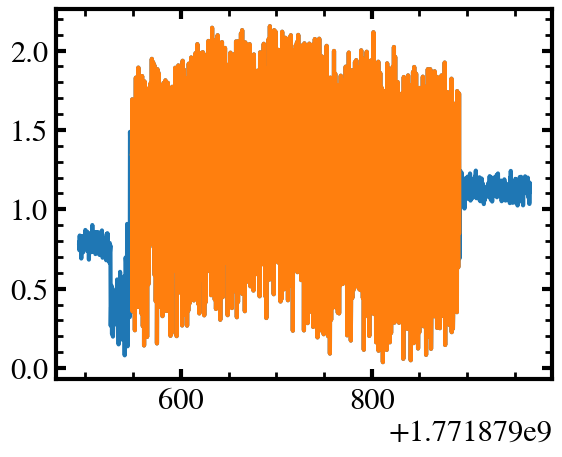

In [7]:
plt.figure()
# plt.plot(interferogram)
plt.plot(top_ts, amplitude)
plt.plot(t_amp, amp)

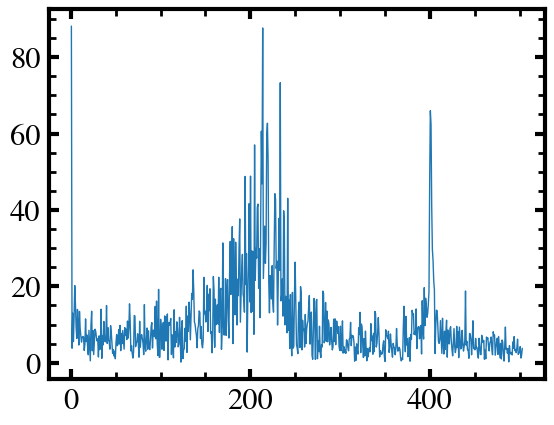

In [8]:
plt.figure()
# plt.plot(pos_on_amp, interferogram, lw=1)
plt.plot(freqs, pspec, lw=1)
plt.show()